<a href="https://colab.research.google.com/github/beyonddbold-ux/ML-Models/blob/main/Predictive_air_temperature.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Loading the dataset



In [7]:
import pandas as pd

df = pd.read_csv('/content/AirTemp.csv')
display(df.head())

,Year,Month,AvgTemp
0,1920,Jan,40.6
1,1920,Feb,40.8
2,1920,Mar,44.4
3,1920,Apr,46.7
4,1920,May,54.1


### Exploring Data Types, Missing Values, and Descriptive Statistics

In [8]:
print(df['AvgTemp'].describe())

count    240.000000
mean      49.041250
std        8.569705
min       31.300000
25%       41.550000
50%       47.350000
75%       57.000000
max       66.500000
Name: AvgTemp, dtype: float64


In [9]:
print('Missing values in the DataFrame:')
print(df.isnull().sum())

Missing values in the DataFrame:
Year       0
Month      0
AvgTemp    0
dtype: int64


## Visualize Average Temperature Trend

### Subtask:
Create a line plot to visualize the trend of average temperature over time, using the 'Year' and 'Month' columns to represent the time axis and 'AvgTemp' for the temperature values. Ensure proper labels and a legend if necessary.

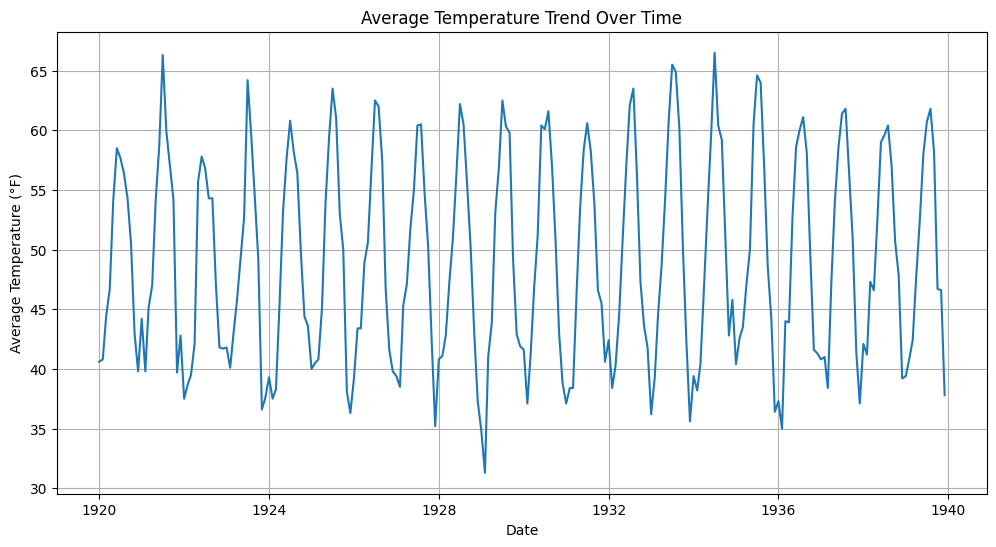

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a 'Date' column from 'Year' and 'Month' with explicit format
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str), format='%Y-%b')

# Set the 'Date' column as the index for time series plotting
df_indexed = df.set_index('Date')

# Plot the average temperature trend
plt.figure(figsize=(12, 6))
sns.lineplot(x=df_indexed.index, y=df_indexed['AvgTemp'])
plt.title('Average Temperature Trend Over Time')
plt.xlabel('Date')
plt.ylabel('Average Temperature (°F)')
plt.grid(True)
plt.show()

The line plot reveals a very strong and consistent seasonal pattern. Each year follows a similar peak-and-valley cycle corresponding to seasonal changes. While there is significant annual oscillation, the overall long-term average temperature appears relatively stable over this 20-year window, without a drastic upward or downward trend visible to the naked eye.

## Task 2: Moving Average Analysis

We will now compute and compare moving averages with different window sizes (3, 5, and 7 months) to observe how they smooth the seasonal fluctuations in the temperature data.

In [11]:
# Compute Moving Averages
df_indexed['MA_3'] = df_indexed['AvgTemp'].rolling(window=3).mean()
df_indexed['MA_5'] = df_indexed['AvgTemp'].rolling(window=5).mean()
df_indexed['MA_7'] = df_indexed['AvgTemp'].rolling(window=7).mean()

# Display the first few rows to see the new columns
display(df_indexed[['AvgTemp', 'MA_3', 'MA_5', 'MA_7']].head(10))

,AvgTemp,MA_3,MA_5,MA_7
Date,,,,
1920-01-01,40.6,NaN,NaN,NaN
1920-02-01,40.8,NaN,NaN,NaN
1920-03-01,44.4,41.933333,NaN,NaN
1920-04-01,46.7,43.966667,NaN,NaN
1920-05-01,54.1,48.400000,45.32,NaN
1920-06-01,58.5,53.100000,48.90,NaN
1920-07-01,57.7,56.766667,52.28,48.971429
1920-08-01,56.4,57.533333,54.68,51.228571
1920-09-01,54.3,56.133333,56.20,53.157143


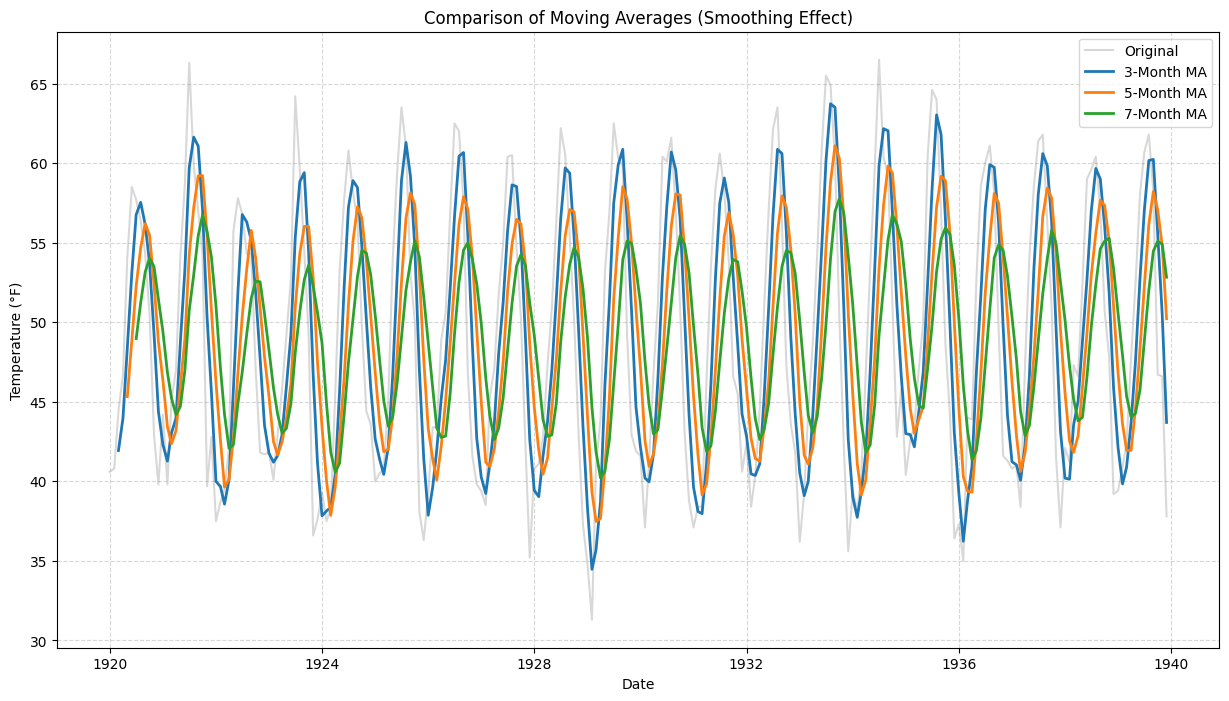

In [12]:
# Visualize the Smoothing Effect
plt.figure(figsize=(15, 8))
plt.plot(df_indexed.index, df_indexed['AvgTemp'], label='Original', alpha=0.3, color='gray')
plt.plot(df_indexed.index, df_indexed['MA_3'], label='3-Month MA', linewidth=2)
plt.plot(df_indexed.index, df_indexed['MA_5'], label='5-Month MA', linewidth=2)
plt.plot(df_indexed.index, df_indexed['MA_7'], label='7-Month MA', linewidth=2)

plt.title('Comparison of Moving Averages (Smoothing Effect)')
plt.xlabel('Date')
plt.ylabel('Temperature (°F)')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

### Explanation of Smoothing

*   **Smoothing Effect**: Moving averages reduce the impact of short-term variations (the sharp peaks and valleys seen in the 'Original' gray line).
*   **Window Size Comparison**:
    *   The **3-month MA** stays close to the original data but rounds off the sharpest corners.
    *   The **7-month MA** provides a much flatter line, highlighting the mid-term trend rather than the monthly volatility.
*   **Insight**: As the window size increases, the lag increases, but the resulting curve becomes significantly smoother, making it easier to spot long-term shifts in the baseline temperature.

=== PERFORMANCE METRICS COMPARISON ===
SMA-3 -> MAE: 3.865 | RMSE: 4.559 | MAPE: 8.02%
WMA-3 -> MAE: 2.622 | RMSE: 3.116 | MAPE: 5.44%


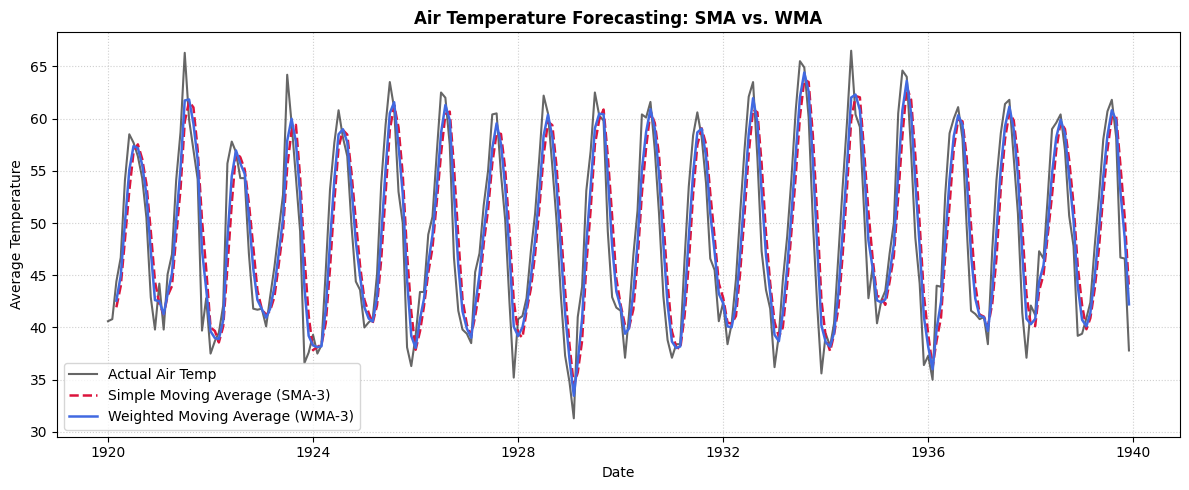

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the AirTemp.csv dataset
df = pd.read_csv("AirTemp.csv")

# Create a continuous time/date column if needed, or use the temperature series directly
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'], format='%Y-%b')
df = df.sort_values('Date').reset_index(drop=True)

# Select window size k (e.g., k = 3 months)
k = 3

# ---------------------------------------------------------
# Step 1: Design an Appropriate Weighting Scheme
# ---------------------------------------------------------
# A linearly increasing weighting scheme places higher emphasis on the most recent observations:
# Raw weights: [1, 2, 3] (where 3 is the most recent month)
weights = np.arange(1, k + 1)
weights_normalized = weights / weights.sum()  # Normalized: [1/6, 2/6, 3/6] -> [0.1667, 0.3333, 0.5000]

# ---------------------------------------------------------
# Step 2: Compute Moving Averages (SMA & WMA)
# ---------------------------------------------------------
# Simple Moving Average (SMA-3)
df['SMA_3'] = df['AvgTemp'].rolling(window=k).mean()

# Weighted Moving Average (WMA-3)
def calc_wma(window):
    return np.dot(window, weights_normalized)

df['WMA_3'] = df['AvgTemp'].rolling(window=k).apply(calc_wma, raw=True)

# ---------------------------------------------------------
# Step 3: Compare Performance (Metrics & Plot)
# ---------------------------------------------------------
# Drop initial NaN rows created by the rolling window for fair comparison
eval_df = df.dropna().copy()

# Mean Absolute Error (MAE)
mae_sma = np.mean(np.abs(eval_df['AvgTemp'] - eval_df['SMA_3']))
mae_wma = np.mean(np.abs(eval_df['AvgTemp'] - eval_df['WMA_3']))

# Root Mean Squared Error (RMSE)
rmse_sma = np.sqrt(np.mean((eval_df['AvgTemp'] - eval_df['SMA_3'])**2))
rmse_wma = np.sqrt(np.mean((eval_df['AvgTemp'] - eval_df['WMA_3'])**2))

# Mean Absolute Percentage Error (MAPE)
mape_sma = np.mean(np.abs((eval_df['AvgTemp'] - eval_df['SMA_3']) / eval_df['AvgTemp'])) * 100
mape_wma = np.mean(np.abs((eval_df['AvgTemp'] - eval_df['WMA_3']) / eval_df['AvgTemp'])) * 100

print("=== PERFORMANCE METRICS COMPARISON ===")
print(f"SMA-3 -> MAE: {mae_sma:.3f} | RMSE: {rmse_sma:.3f} | MAPE: {mape_sma:.2f}%")
print(f"WMA-3 -> MAE: {mae_wma:.3f} | RMSE: {rmse_wma:.3f} | MAPE: {mape_wma:.2f}%")

# Plotting the Results
plt.figure(figsize=(12, 5))
plt.plot(df['Date'], df['AvgTemp'], label='Actual Air Temp', color='black', alpha=0.6, linewidth=1.5)
plt.plot(df['Date'], df['SMA_3'], label='Simple Moving Average (SMA-3)', color='crimson', linestyle='--', linewidth=1.8)
plt.plot(df['Date'], df['WMA_3'], label='Weighted Moving Average (WMA-3)', color='royalblue', linewidth=1.8)

plt.title('Air Temperature Forecasting: SMA vs. WMA', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Temperature')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

Total Observations: 240
Training Set Size:  192 rows
Testing Set Size:   48 rows

              OLS REGRESSION SUMMARY
                            OLS Regression Results                            
Dep. Variable:                AvgTemp   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.5102
Date:                Wed, 12 Aug 2026   Prob (F-statistic):              0.476
Time:                        10:44:18   Log-Likelihood:                -685.36
No. Observations:                 192   AIC:                             1375.
Df Residuals:                     190   BIC:                             1381.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------

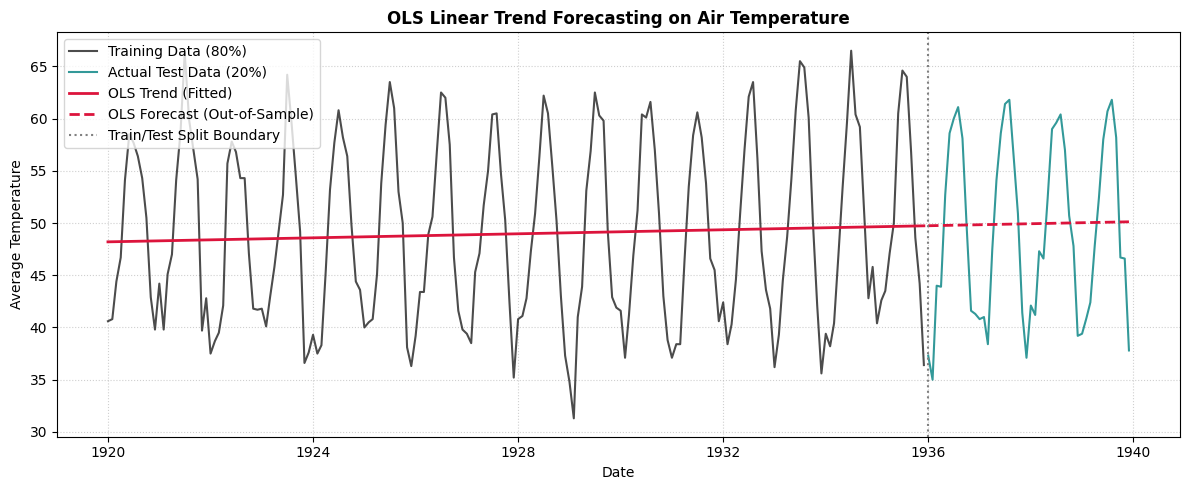

In [17]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Step 1: Load Data & Create Time Index
# ---------------------------------------------------------
df = pd.read_csv("AirTemp.csv")

# Combine Year and Month into a continuous Datetime object and sort chronologically
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'], format='%Y-%b')
df = df.sort_values('Date').reset_index(drop=True)

# Create a sequential numeric time index (t = 0, 1, 2, ..., N-1)
df['Time_Index'] = np.arange(len(df))

# ---------------------------------------------------------
# Step 2: Split Dataset into Training (80%) and Testing (20%)
# ---------------------------------------------------------
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

print(f"Total Observations: {len(df)}")
print(f"Training Set Size:  {len(train_df)} rows")
print(f"Testing Set Size:   {len(test_df)} rows")

# ---------------------------------------------------------
# Step 3: Develop OLS Forecasting Model
# ---------------------------------------------------------
# Define dependent (y) and independent (X) variables for training
X_train = sm.add_constant(train_df['Time_Index'])  # Adds intercept (β0)
y_train = train_df['AvgTemp']

# Fit OLS model
ols_model = sm.OLS(y_train, X_train).fit()

# Print statistical summary
print("\n" + "="*50)
print("              OLS REGRESSION SUMMARY")
print("="*50)
print(ols_model.summary())

# Extract coefficients for interpretation
intercept = ols_model.params['const']
slope = ols_model.params['Time_Index']

print("\n---------------------------------------------------")
print(f"REGRESSION EQUATION: AvgTemp = {intercept:.4f} + ({slope:.4f} * Time_Index)")
print("---------------------------------------------------")

# ---------------------------------------------------------
# Step 4: Forecast the Testing Period
# ---------------------------------------------------------
# Prepare test features with constant
X_test = sm.add_constant(test_df['Time_Index'])

# Predict on testing set
test_df['Forecast'] = ols_model.predict(X_test)
train_df['Fitted'] = ols_model.predict(X_train)

# Compute forecast error evaluation metrics
mae = np.mean(np.abs(test_df['AvgTemp'] - test_df['Forecast']))
rmse = np.sqrt(np.mean((test_df['AvgTemp'] - test_df['Forecast'])**2))
mape = np.mean(np.abs((test_df['AvgTemp'] - test_df['Forecast']) / test_df['AvgTemp'])) * 100

print("\n=== OUT-OF-SAMPLE TEST FORECAST ACCURACY ===")
print(f"Mean Absolute Error (MAE):                   {mae:.3f}")
print(f"Root Mean Squared Error (RMSE):             {rmse:.3f}")
print(f"Mean Absolute Percentage Error (MAPE):      {mape:.2f}%")

# ---------------------------------------------------------
# Plotting Train, Test, and OLS Forecast Line
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(train_df['Date'], train_df['AvgTemp'], label='Training Data (80%)', color='black', alpha=0.7)
plt.plot(test_df['Date'], test_df['AvgTemp'], label='Actual Test Data (20%)', color='teal', alpha=0.8)

# Combined Trend Line across entire horizon
plt.plot(train_df['Date'], train_df['Fitted'], label='OLS Trend (Fitted)', color='crimson', linewidth=2)
plt.plot(test_df['Date'], test_df['Forecast'], label='OLS Forecast (Out-of-Sample)', color='crimson', linestyle='--', linewidth=2)

plt.title('OLS Linear Trend Forecasting on Air Temperature', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Temperature')
plt.axvline(x=test_df['Date'].iloc[0], color='gray', linestyle=':', label='Train/Test Split Boundary')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

R-squared:               0.0027
Durbin-Watson Statistic: 0.3723
Test Set RMSE:           8.3510


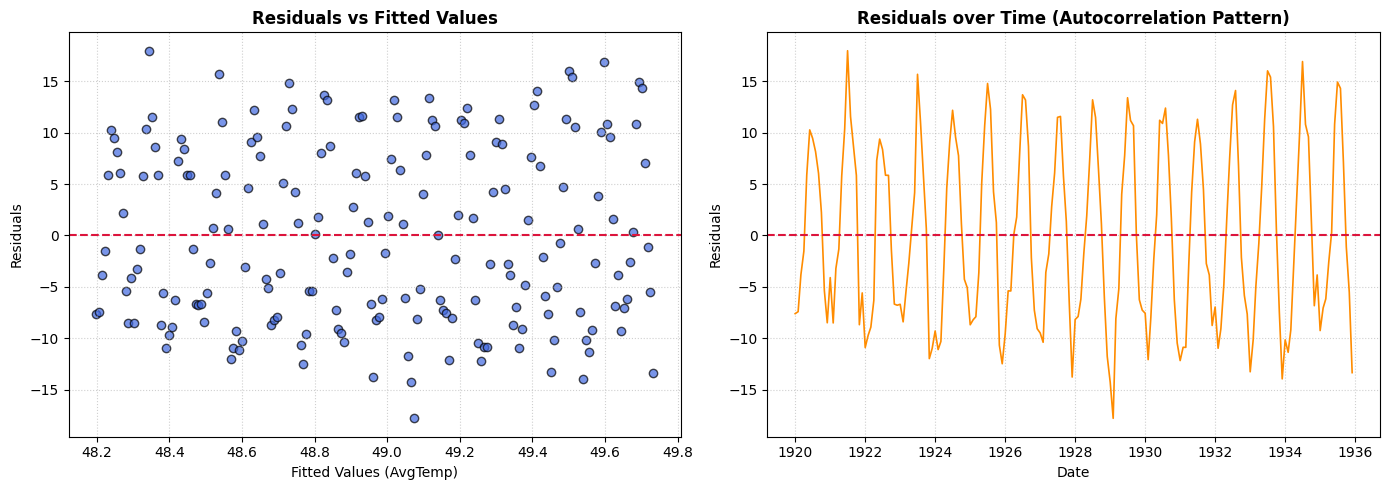

In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.stattools import durbin_watson

# 1. Load Data & Prepare Time Index
df = pd.read_csv("AirTemp.csv")
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'], format='%Y-%b')
df = df.sort_values('Date').reset_index(drop=True)
df['Time_Index'] = np.arange(len(df))

# 2. Train-Test Split (80/20)
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

# 3. Fit OLS Model
X_train = sm.add_constant(train_df['Time_Index'])
y_train = train_df['AvgTemp']
ols_model = sm.OLS(y_train, X_train).fit()

# Residuals and Fitted values
train_df['Fitted'] = ols_model.predict(X_train)
residuals = ols_model.resid

# 4. Diagnostic Metrics
r_squared = ols_model.rsquared
dw_stat = durbin_watson(residuals)

X_test = sm.add_constant(test_df['Time_Index'])
test_df['Forecast'] = ols_model.predict(X_test)
rmse = np.sqrt(np.mean((test_df['AvgTemp'] - test_df['Forecast'])**2))

print(f"R-squared:               {r_squared:.4f}")
print(f"Durbin-Watson Statistic: {dw_stat:.4f}")
print(f"Test Set RMSE:           {rmse:.4f}")

# 5. Plot Residual Diagnostics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Residuals vs Fitted
axes[0].scatter(train_df['Fitted'], residuals, color='royalblue', alpha=0.7, edgecolors='k')
axes[0].axhline(y=0, color='crimson', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Fitted Values (AvgTemp)')
axes[0].set_ylabel('Residuals')
axes[0].grid(True, linestyle=':', alpha=0.6)

# Plot 2: Residuals over Time
axes[1].plot(train_df['Date'], residuals, color='darkorange', linewidth=1.2)
axes[1].axhline(y=0, color='crimson', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals over Time (Autocorrelation Pattern)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Residuals')
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

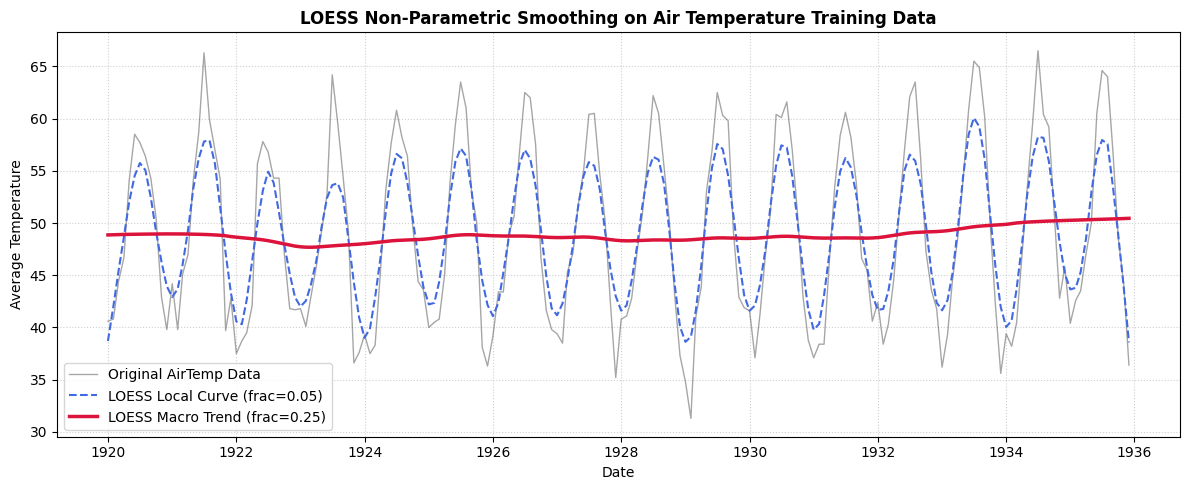

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.smoothers_lowess import lowess

# ---------------------------------------------------------
# Step 1: Load Data & Train-Test Split (80%)
# ---------------------------------------------------------
df = pd.read_csv("AirTemp.csv")
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'], format='%Y-%b')
df = df.sort_values('Date').reset_index(drop=True)
df['Time_Index'] = np.arange(len(df))

# 80% Training Data
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()

# ---------------------------------------------------------
# Step 2: Apply LOESS Smoothing
# ---------------------------------------------------------
# frac determines the proportion of data used in each local regression window

# Short-window LOESS (frac=0.05) captures local non-linear seasonal cycles
loess_seasonal = lowess(train_df['AvgTemp'], train_df['Time_Index'], frac=0.05)

# Long-window LOESS (frac=0.25) extracts the smooth underlying trend line
loess_trend = lowess(train_df['AvgTemp'], train_df['Time_Index'], frac=0.25)

train_df['LOESS_Seasonal'] = loess_seasonal[:, 1]
train_df['LOESS_Trend'] = loess_trend[:, 1]

# ---------------------------------------------------------
# Step 3: Plot LOESS Trend vs. Original Data
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))

# Original Data
plt.plot(train_df['Date'], train_df['AvgTemp'], label='Original AirTemp Data', color='black', alpha=0.35, linewidth=1)

# LOESS Non-Linear Seasonal Curve
plt.plot(train_df['Date'], train_df['LOESS_Seasonal'], label='LOESS Local Curve (frac=0.05)', color='royalblue', linestyle='--', linewidth=1.5)

# LOESS Underlying Macro Trend
plt.plot(train_df['Date'], train_df['LOESS_Trend'], label='LOESS Macro Trend (frac=0.25)', color='crimson', linewidth=2.5)

plt.title('LOESS Non-Parametric Smoothing on Air Temperature Training Data', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Temperature')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

=== OUT-OF-SAMPLE ACCURACY COMPARISON ===
Simple OLS  -> MAE: 7.472 | RMSE: 8.351 | MAPE: 15.85%
OLS + LOESS -> MAE: 7.457 | RMSE: 8.341 | MAPE: 15.77%


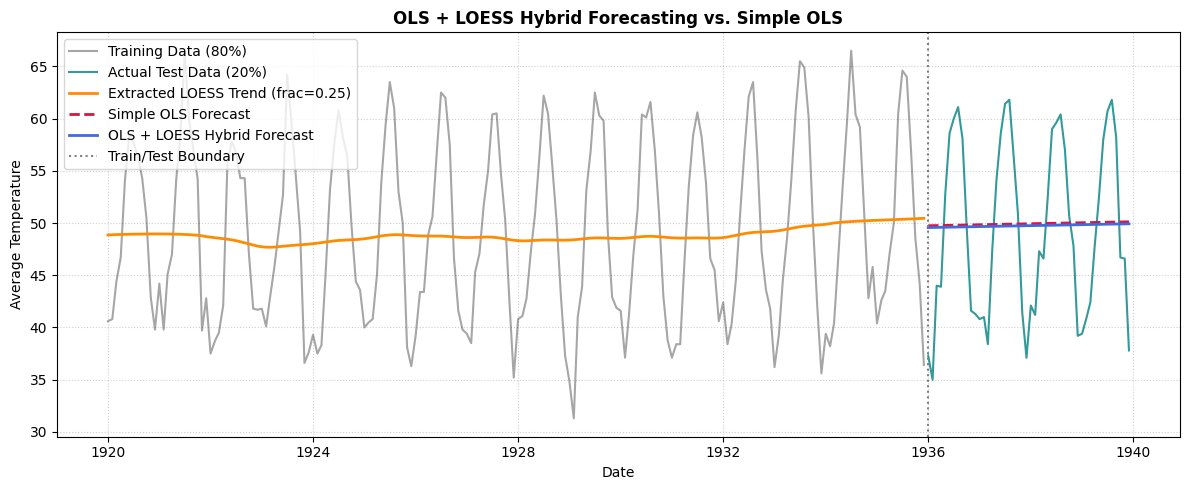

In [20]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# Step 1: Load Data & Train-Test Split (80/20)
# ---------------------------------------------------------
df = pd.read_csv("AirTemp.csv")
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'], format='%Y-%b')
df = df.sort_values('Date').reset_index(drop=True)
df['Time_Index'] = np.arange(len(df))

train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy()
test_df = df.iloc[train_size:].copy()

# ---------------------------------------------------------
# Step 2: Fit Simple OLS (Task 4 Baseline)
# ---------------------------------------------------------
X_train_simple = sm.add_constant(train_df['Time_Index'])
simple_ols = sm.OLS(train_df['AvgTemp'], X_train_simple).fit()

X_test_simple = sm.add_constant(test_df['Time_Index'])
test_df['Forecast_Simple_OLS'] = simple_ols.predict(X_test_simple)

# ---------------------------------------------------------
# Step 3: Extract LOESS Trend & Fit OLS on Smoothed Data
# ---------------------------------------------------------
# Extract non-parametric trend (frac = 0.25)
loess_out = lowess(train_df['AvgTemp'], train_df['Time_Index'], frac=0.25)
train_df['LOESS_Trend'] = loess_out[:, 1]

# Fit OLS model on the LOESS Trend
X_train_loess = sm.add_constant(train_df['Time_Index'])
ols_loess_model = sm.OLS(train_df['LOESS_Trend'], X_train_loess).fit()

# Forecast the testing period
X_test_loess = sm.add_constant(test_df['Time_Index'])
test_df['Forecast_OLS_LOESS'] = ols_loess_model.predict(X_test_loess)

# ---------------------------------------------------------
# Step 4: Compare Forecasting Accuracy
# ---------------------------------------------------------
# Simple OLS Metrics
mae_simple = np.mean(np.abs(test_df['AvgTemp'] - test_df['Forecast_Simple_OLS']))
rmse_simple = np.sqrt(np.mean((test_df['AvgTemp'] - test_df['Forecast_Simple_OLS'])**2))
mape_simple = np.mean(np.abs((test_df['AvgTemp'] - test_df['Forecast_Simple_OLS']) / test_df['AvgTemp'])) * 100

# OLS + LOESS Hybrid Metrics
mae_hybrid = np.mean(np.abs(test_df['AvgTemp'] - test_df['Forecast_OLS_LOESS']))
rmse_hybrid = np.sqrt(np.mean((test_df['AvgTemp'] - test_df['Forecast_OLS_LOESS'])**2))
mape_hybrid = np.mean(np.abs((test_df['AvgTemp'] - test_df['Forecast_OLS_LOESS']) / test_df['AvgTemp'])) * 100

print("=== OUT-OF-SAMPLE ACCURACY COMPARISON ===")
print(f"Simple OLS  -> MAE: {mae_simple:.3f} | RMSE: {rmse_simple:.3f} | MAPE: {mape_simple:.2f}%")
print(f"OLS + LOESS -> MAE: {mae_hybrid:.3f} | RMSE: {rmse_hybrid:.3f} | MAPE: {mape_hybrid:.2f}%")

# ---------------------------------------------------------
# Step 5: Visualization
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(train_df['Date'], train_df['AvgTemp'], label='Training Data (80%)', color='black', alpha=0.35)
plt.plot(test_df['Date'], test_df['AvgTemp'], label='Actual Test Data (20%)', color='teal', alpha=0.8)

plt.plot(train_df['Date'], train_df['LOESS_Trend'], label='Extracted LOESS Trend (frac=0.25)', color='darkorange', linewidth=2)
plt.plot(test_df['Date'], test_df['Forecast_Simple_OLS'], label='Simple OLS Forecast', color='crimson', linestyle='--', linewidth=2)
plt.plot(test_df['Date'], test_df['Forecast_OLS_LOESS'], label='OLS + LOESS Hybrid Forecast', color='royalblue', linewidth=2)

plt.axvline(x=test_df['Date'].iloc[0], color='gray', linestyle=':', label='Train/Test Boundary')
plt.title('OLS + LOESS Hybrid Forecasting vs. Simple OLS', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Temperature')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


=== EXPONENTIAL SMOOTHING ACCURACY ===
SES          -> MAE: 13.000 | RMSE: 15.397 | MAPE: 24.21%
Holt-Winters -> MAE: 1.576 | RMSE: 2.112 | MAPE: 3.48%


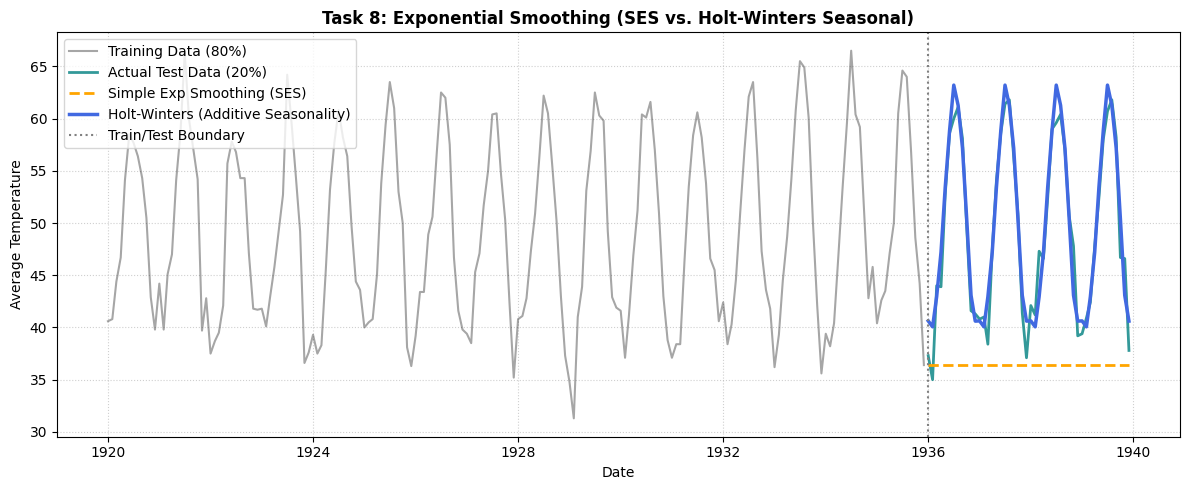

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing

# ---------------------------------------------------------
# Step 1: Load Data & Prepare Train/Test Sets
# ---------------------------------------------------------
df = pd.read_csv("AirTemp.csv")
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'], format='%Y-%b')
df = df.sort_values('Date').reset_index(drop=True)

# 80/20 Train-Test Split with Datetime Index
train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size].copy().set_index('Date')
test_df = df.iloc[train_size:].copy().set_index('Date')

# ---------------------------------------------------------
# Step 2: Fit Exponential Smoothing Models
# ---------------------------------------------------------
# 1. Simple Exponential Smoothing (SES - Level Only)
ses_model = SimpleExpSmoothing(train_df['AvgTemp']).fit(optimized=True)
test_df['Forecast_SES'] = ses_model.forecast(len(test_df))

# 2. Holt-Winters Exponential Smoothing (Level + Trend + 12-Month Seasonality)
hw_model = ExponentialSmoothing(
    train_df['AvgTemp'],
    seasonal='add',
    seasonal_periods=12
).fit(optimized=True)
test_df['Forecast_HW'] = hw_model.forecast(len(test_df))

# ---------------------------------------------------------
# Step 3: Performance Evaluation
# ---------------------------------------------------------
def calc_metrics(actual, forecast):
    mae = np.mean(np.abs(actual - forecast))
    rmse = np.sqrt(np.mean((actual - forecast)**2))
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    return mae, rmse, mape

mae_ses, rmse_ses, mape_ses = calc_metrics(test_df['AvgTemp'], test_df['Forecast_SES'])
mae_hw, rmse_hw, mape_hw = calc_metrics(test_df['AvgTemp'], test_df['Forecast_HW'])

print("=== EXPONENTIAL SMOOTHING ACCURACY ===")
print(f"SES          -> MAE: {mae_ses:.3f} | RMSE: {rmse_ses:.3f} | MAPE: {mape_ses:.2f}%")
print(f"Holt-Winters -> MAE: {mae_hw:.3f} | RMSE: {rmse_hw:.3f} | MAPE: {mape_hw:.2f}%")

# ---------------------------------------------------------
# Step 4: Visualization
# ---------------------------------------------------------
plt.figure(figsize=(12, 5))
plt.plot(train_df.index, train_df['AvgTemp'], label='Training Data (80%)', color='black', alpha=0.35)
plt.plot(test_df.index, test_df['AvgTemp'], label='Actual Test Data (20%)', color='teal', alpha=0.8, linewidth=2)

plt.plot(test_df.index, test_df['Forecast_SES'], label='Simple Exp Smoothing (SES)', color='orange', linestyle='--', linewidth=2)
plt.plot(test_df.index, test_df['Forecast_HW'], label='Holt-Winters (Additive Seasonality)', color='royalblue', linewidth=2.5)

plt.axvline(x=test_df.index[0], color='gray', linestyle=':', label='Train/Test Boundary')
plt.title('Task 8: Exponential Smoothing (SES vs. Holt-Winters Seasonal)', fontsize=12, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Temperature')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()
